In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd

# Import and analyse noise dataset

In [ ]:
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
noise_streets['fid'] = noise_streets.index # Assign explicitly a numeric FID
print(noise_streets.crs)  #CRS = Coordinate Reference System
print(noise_streets.shape)
print(noise_streets.columns.tolist())
print("Number of street segments:", len(noise_streets))

EPSG:25831
(15115, 30)
['TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'TOTAL_DEN', 'TRANSIT_D', 'TRANSIT_E', 'TRANSIT_N', 'TRANSIT_DEN', 'GI_TR_D', 'GI_TR_E', 'GI_TR_N', 'GI_TR_DEN', 'FFCC_D', 'FFCC_E', 'FFCC_N', 'FFCC_DEN', 'INDUST_D', 'INDUST_E', 'INDUST_N', 'INDUST_DEN', 'VIANANTS_D', 'VIANANTS_E', 'OCI_N', 'PATIS_D', 'PATIS_E', 'geometry_type', 'start', 'end', 'geometry']
Number of street segments: 15115


## Traffic Signals - OSM

In [3]:
signals = ox.features_from_place("Barcelona, Spain", tags={"highway": "traffic_signals"}) #connects to OSM and downloads all features within Barcelona that match the tags you specify
signals = signals[signals.geometry.type == 'Point'].to_crs(noise_streets.crs) #keeps only point geometries and reprojects to match the CRS of noise_streets (otherwise they come in EPSG:4326)
print(signals.crs)
print(signals.columns.tolist())
#signals.plot(figsize=(10, 10),  column='traffic_signals', legend=True, markersize=2)

#https://osmnx.readthedocs.io/en/stable/user-reference.html#osmnx.features.features_from_place

EPSG:25831
['geometry', 'highway', 'traffic_signals', 'traffic_signals:direction', 'crossing', 'button_operated', 'tactile_paving', 'traffic_signals:sound', 'traffic_signals:vibration', 'crossing:markings', 'bicycle', 'source', 'kerb', 'wheelchair', 'colour', 'mapillary', 'segregated', 'check_date:traffic_signals:vibration', 'description', 'check_date:traffic_signals:sound', 'crossing:signals', 'direction', 'supervised', 'barrier', 'red_turn:bicycle', 'name', 'name:ca', 'check_date:tactile_paving', 'was:traffic_signals:direction', 'traffic_signals:sound:remote_operated', 'proposed:highway', 'camera:mount', 'camera:type', 'man_made', 'surveillance', 'surveillance:type']


Analyse signals dataset

In [4]:
print(f"Total signals: {len(signals)}")
print(f"Non-null traffic_signals: {signals['traffic_signals'].notna().sum()}")
print(f"Null traffic_signals: {signals['traffic_signals'].isna().sum()}")
print("\nValue counts:")
print(signals['traffic_signals'].value_counts(dropna=False))

Total signals: 6198
Non-null traffic_signals: 1687
Null traffic_signals: 4511

Value counts:
traffic_signals
NaN                    4511
signal                 1463
pedestrian_crossing     149
blinker                  42
traffic_lights           25
crossing                  8
Name: count, dtype: int64


NOTE: most of the traffic signals have no category. 
We might want to check if they are relevant for noise prediction or not.

Filter relevant Traffic signals

Original: (6198, 36), Filtered: (6148, 36)


Text(0.5, 1.0, 'Relevant Traffic Signals')

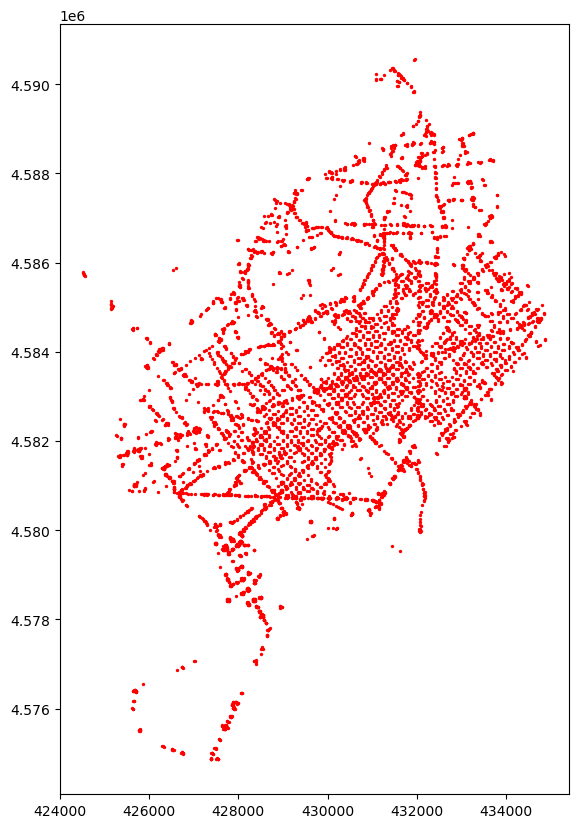

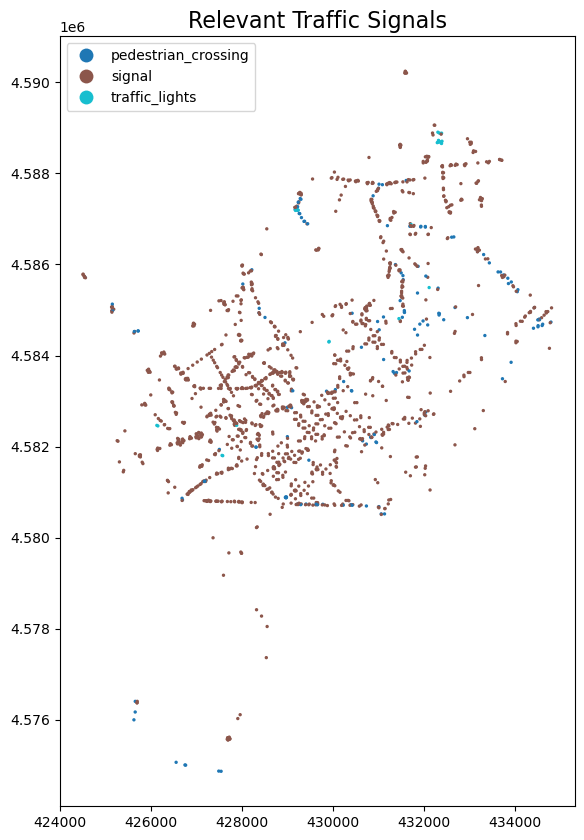

In [5]:
signals_categories = ['traffic_lights', 'signal', 'pedestrian_crossing'] 
signals_filtered = signals[signals['traffic_signals'].isin(signals_categories) | 
    signals['traffic_signals'].isna()]  #keep rows where traffic_signals is in the specified categories or is null
print(f"Original: {signals.shape}, Filtered: {signals_filtered.shape}")
signals_filtered.plot(figsize=(10, 10), color='red', markersize=2) #plot all signals including NaN
ax = signals_filtered.plot(figsize=(10, 10), column='traffic_signals', legend=True, markersize=2) #plot signals by category
ax.set_title("Relevant Traffic Signals", fontsize=16)

## Points Of Interest (POIs) - OSM

In [6]:
pois = ox.features_from_place(
    "Barcelona, Spain",
    tags={"amenity": True}   # all amenities — adjust tags as needed
)
pois = pois[pois.geometry.type == "Point"].to_crs(noise_streets.crs)
print(pois.crs)
print(pois.columns.tolist())
#pois.plot(figsize=(10, 10), column='amenity', legend=True, markersize=2)

EPSG:25831
['geometry', 'access', 'amenity', 'fee', 'maxheight', 'parking', 'addr:city', 'addr:full', 'addr:housenumber', 'addr:postcode', 'addr:street', 'check_date', 'contact:phone', 'dispensing', 'healthcare', 'name', 'name:ca', 'ref', 'source', 'source:date', 'opening_hours', 'phone', 'website', 'wheelchair', 'alt_name', 'contact:instagram', 'opening_hours:signed', 'location', 'recycling:cans', 'recycling:food_waste', 'recycling:glass_bottles', 'recycling:green_waste', 'recycling:paper', 'recycling:plastic', 'recycling_type', 'lit', 'man_made', 'operator', 'operator:wikidata', 'capacity', 'recycling:waste', 'short_name', 'brand', 'brand:wikidata', 'brand:wikipedia', 'cuisine', 'diet:gluten_free', 'internet_access', 'takeaway', 'toilets', 'toilets:wheelchair', 'indoor_seating', 'outdoor_seating', 'layer', 'designation', 'recycling:batteries', 'recycling:books', 'recycling:cardboard', 'recycling:cartons', 'recycling:clothes', 'recycling:electrical_appliances', 'recycling:magazines', 

Filter relevant POIs 

Original: 30185, Filtered: 9485


Text(0.5, 1.0, 'Amenities by Category')

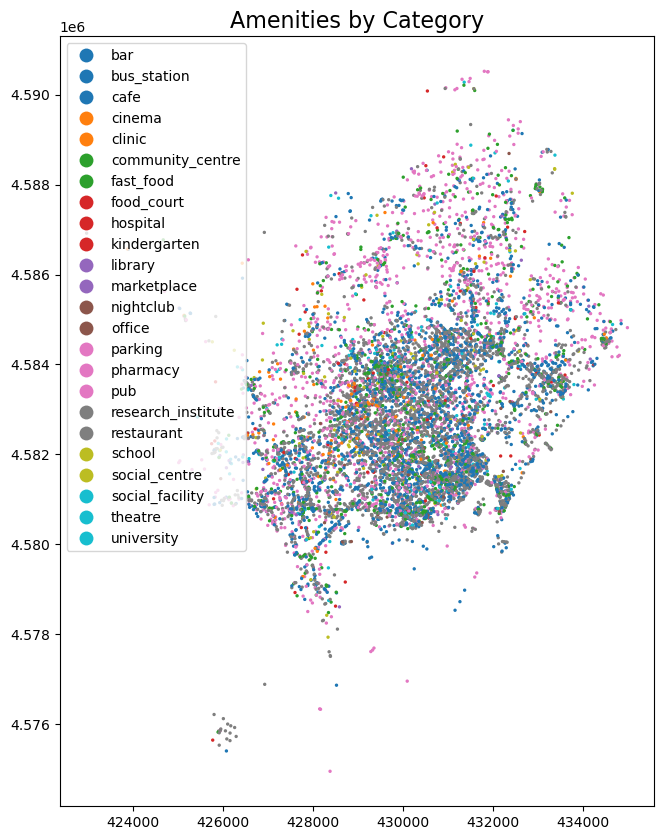

In [7]:
# Amenities likely to affect or be affected by noise
categories = [
    'restaurant', 'cafe', 'bar', 'pub', 'nightclub', 'fast_food', 'food_court', # Entertainment/food
    'school', 'research_institute','university', 'library', 'kindergarten',  # Education (noise sensitive)
    'hospital', 'clinic', 'pharmacy',  # Health (noise sensitive)
    'shopping_mall', 'shop', 'supermarket', 'marketplace', # Commerce (traffic noise)
    'parking', 'parking_lot', 'taxi'  # Traffic noise
    'station', 'bus_station', 'train_station',  # Transport noise
    'hotel', 'hostel',  # Accommodation (noise sensitive)
    'office', 'workplace',  # Work areas
    'park', 'playground', 'recreation_ground',  # Recreation
    'music_venue', 'cinema', 'theatre',  # Entertainment
    'social_facility', 'social_centre', 'community_centre'  # Social services (noise sensitive)
]
pois_filtered = pois[pois['amenity'].isin(categories)]
print(f"Original: {len(pois)}, Filtered: {len(pois_filtered)}")
ax =pois_filtered.plot(figsize=(10, 10), column='amenity', legend=True, markersize=2)
ax.set_title("Amenities by Category", fontsize=16)

## Trees - OSM

EPSG:25831
['geometry', 'denotation', 'natural', 'description', 'protected', 'species', 'species:ca', 'website', 'source', 'source:date', 'leaf_type', 'species:es', 'survey:date', 'genus', 'name', 'wikidata', 'wikimedia_commons', 'taxon', 'taxon:en', 'height', 'leaf_cycle', 'name:ca', 'ref', 'start_date', 'trees', 'crown_type', 'shop', 'panoramax', 'note', 'loc_name', 'panoramax:0', 'circumference', 'genus:wikidata', 'historic', 'diameter', 'taxon:family', 'amenity', 'backrest', 'name:es', 'panoramax:1', 'est_height', 'object:street', 'diameter_crown', 'species:wikidata', 'species:wikipedia', 'addr:city', 'genus:ca', 'addr:housenumber', 'addr:postcode', 'addr:street', 'entrance', 'tree', 'taxon:wikidata']


Text(0.5, 1.0, 'Trees')

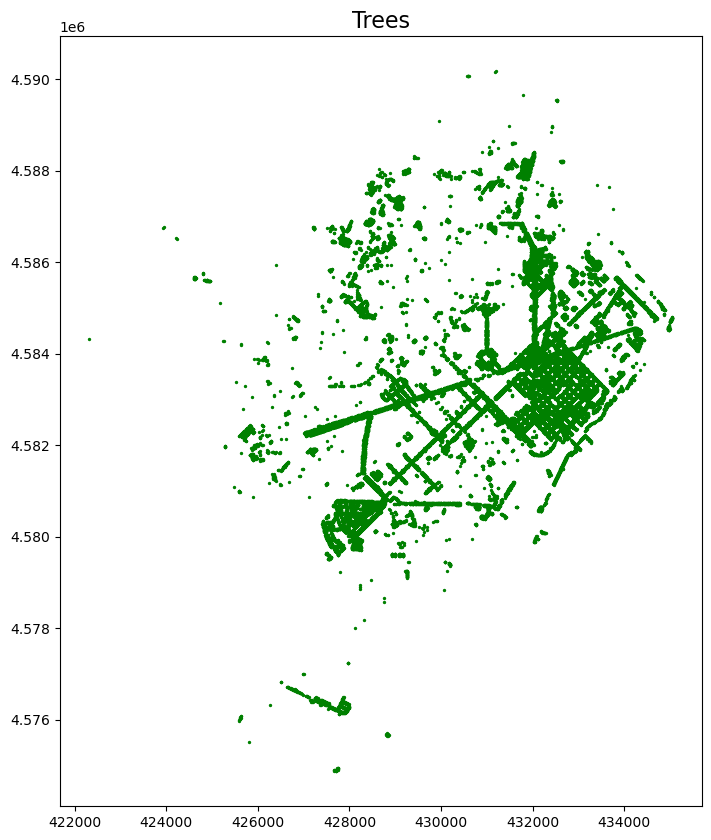

In [8]:
trees = ox.features_from_place(
    "Barcelona, Spain",
    tags={"natural": "tree"} )  # all trees — adjust tags as needed
trees = trees[trees.geometry.type == "Point"].to_crs(noise_streets.crs)
print(trees.crs)
print(trees.columns.tolist())
ax = trees.plot(figsize=(10, 10), color='green', markersize=2)
ax.set_title("Trees", fontsize=16)

## Transport - OSM

NOTE: some Transports are also included in POIs

EPSG:25831
['geometry', 'name', 'name:ca', 'railway', 'wheelchair', 'amenity', 'bench', 'bus', 'highway', 'network', 'operator', 'passenger_information_display', 'public_transport', 'ref', 'route_ref', 'shelter', 'bin', 'lit', 'tactile_paving', 'alt_name', 'alt_name:ca', 'url', 'wheelchair:description', 'bicycle', 'network:short', 'network:wikidata', 'ferry', 'name:ko', 'level', 'check_date:shelter', 'website', 'operator:wikidata', 'owner', 'owner:wikidata', 'ref:EU:PLC', 'train', 'uic_ref', 'kerb', 'kerb:approach_aid', 'passenger_information_display:speech_output', 'network:bus', 'network:guid', 'network:wikipedia', 'tram', 'departures_board', 'defibrillator:access', 'defibrillator:indoor', 'defibrillator:location', 'defibrillator:location:en', 'defibrillator:wheelchair:access', 'emergency', 'panoramax', 'platforms', 'station', 'subway', 'survey:date', 'wikidata', 'wikimedia_commons', 'wikipedia', 'emergency:fire_extinguisher', 'operator:short', 'panoramax:0', 'addr:city', 'addr:house

<Axes: >

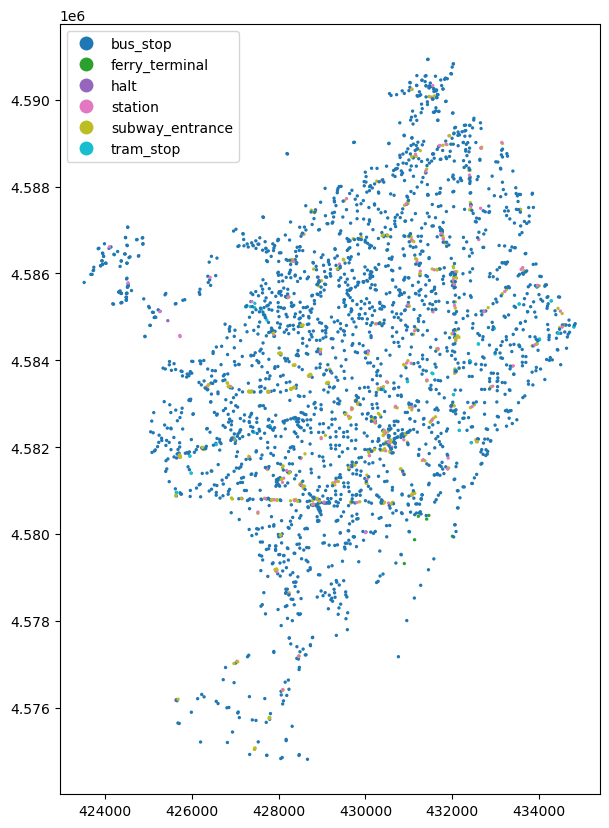

In [9]:
transport = ox.features_from_place(
    "Barcelona, Spain",
    tags={"railway": ["station", "tram_stop", "subway_entrance", "halt"],
          "highway": "bus_stop",
          "amenity": "ferry_terminal"} )  # all transport — adjust tags as needed
transport = transport[transport.geometry.type == "Point"].to_crs(noise_streets.crs)
print(transport.crs)
print(transport.columns.tolist())

transport['transport_type'] = transport['railway'].fillna(transport['highway'].fillna(transport['amenity']))

transport.plot(figsize=(10, 10), column='transport_type', legend=True, markersize=2)

# Buffer streets (50 m) - noise dataset

<Axes: >

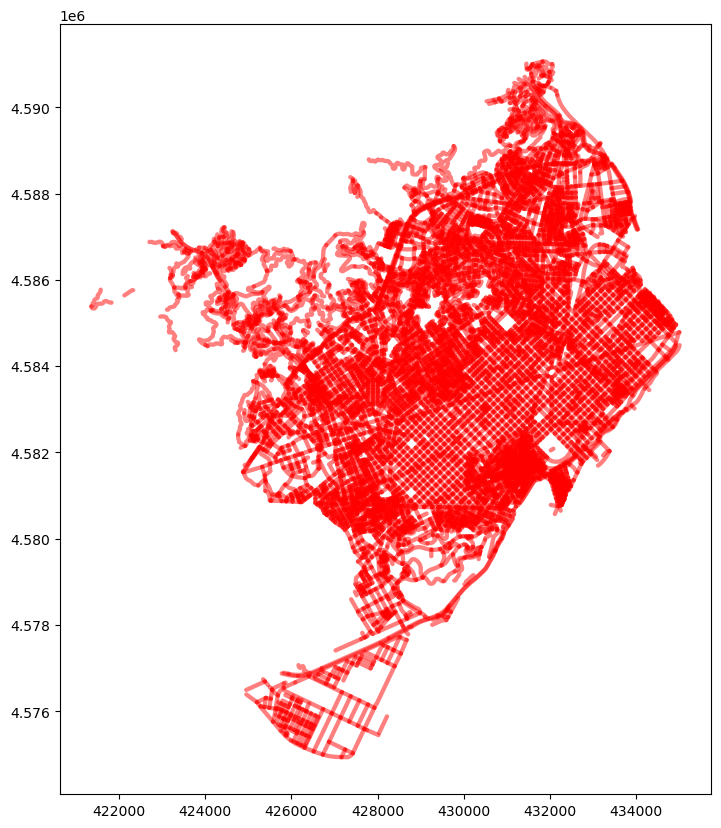

In [10]:
# Create 50m buffer around each street segment
buffered_streets_50 = noise_streets.copy()
buffered_streets_50['geometry'] = noise_streets.geometry.buffer(50) #replacing every shape in the geometry column with a buffered version
buffered_streets_50.plot(figsize=(10, 10), alpha=0.5, color='red')

Count signals per 50m buffer

In [11]:
sig_join_50 = gpd.sjoin(signals_filtered, buffered_streets_50, how="right", predicate="within") #spatial join to combine GeoDataFrames (signals and buffered streets), how="right" to keep all buffered street segments, predicate="within" to match signals that fall within the buffered street segments
sig_counts_50 = sig_join_50.groupby(sig_join_50.index).size().rename("signal_count_50") #groupby() to group by the index of the buffered street segments, size() to count the number of signals in each segment, rename() to rename the resulting Series to "signal_count"
sig_counts_50

0        5
1        1
2        1
3        3
4        1
        ..
15110    4
15111    5
15112    2
15113    5
15114    1
Name: signal_count_50, Length: 15115, dtype: int64

Count POIs per 50m buffer

In [12]:
pois_join_50 = gpd.sjoin(pois_filtered, buffered_streets_50, how="right", predicate="within") 
pois_counts_50 = pois_join_50.groupby(pois_join_50.index).size().rename("poi_count_50")
pois_counts_50

0        2
1        4
2        1
3        5
4        1
        ..
15110    1
15111    6
15112    2
15113    6
15114    1
Name: poi_count_50, Length: 15115, dtype: int64

Count Trees per 50m buffer

In [13]:
trees_join_50 = gpd.sjoin(trees, buffered_streets_50, how="right", predicate="within") 
trees_counts_50 = trees_join_50.groupby(trees_join_50.index).size().rename("tree_count_50")
trees_counts_50

0         2
1         4
2         1
3         1
4         1
         ..
15110     1
15111     7
15112     1
15113    41
15114     1
Name: tree_count_50, Length: 15115, dtype: int64

Count transports per 50m buffer

In [14]:
transport_join_50 = gpd.sjoin(transport, buffered_streets_50, how="right", predicate="within")
transport_counts_50 = transport_join_50.groupby(transport_join_50.index).size().rename("transport_count_50")

# Buffer streets (100 m) - noise dataset

<Axes: >

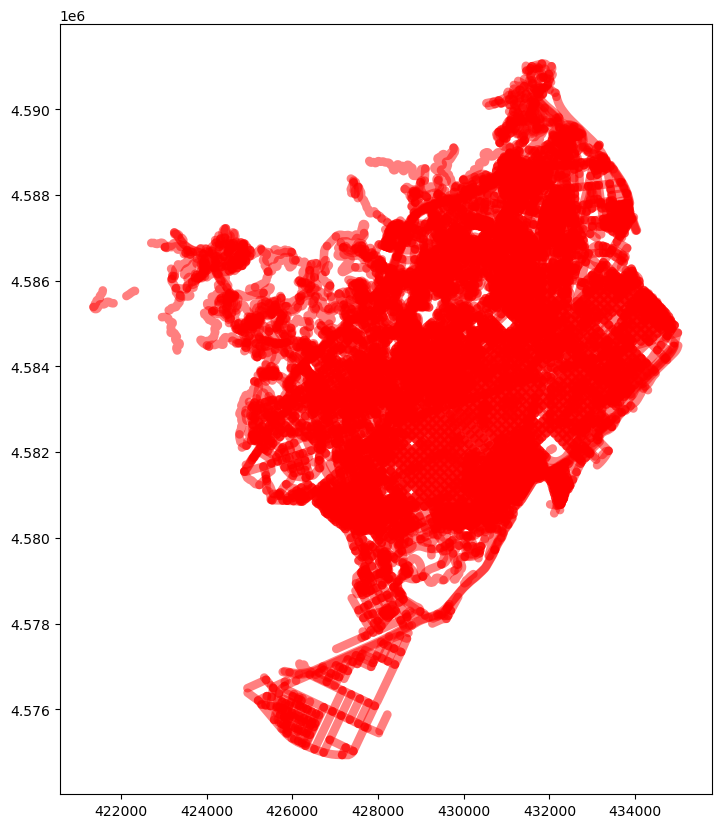

In [15]:
# Create 100m buffer around each street segment
buffered_streets_100 = noise_streets.copy()
buffered_streets_100['geometry'] = noise_streets.geometry.buffer(100) #replacing every shape in the geometry column with a buffered version
buffered_streets_100.plot(figsize=(10, 10), alpha=0.5, color='red')

Count signals per 100m buffer

In [16]:
sig_join_100 = gpd.sjoin(signals_filtered, buffered_streets_100, how="right", predicate="within") #spatial join to combine GeoDataFrames (signals and buffered streets), how="right" to keep all buffered street segments, predicate="within" to match signals that fall within the buffered street segments
sig_counts_100 = sig_join_100.groupby(sig_join_100.index).size().rename("signal_count_100")

Count signals per 100m buffer

In [17]:
pois_join_100 = gpd.sjoin(pois_filtered, buffered_streets_100, how="right", predicate="within") 
pois_counts_100 = pois_join_100.groupby(pois_join_100.index).size().rename("poi_count_100")

Count trees per 100m buffer

In [18]:
trees_join_100 = gpd.sjoin(trees, buffered_streets_100, how="right", predicate="within") 
trees_counts_100 = trees_join_100.groupby(trees_join_100.index).size().rename("tree_count_100")

Count transport per 100m buffer

In [19]:
transport_join_100 = gpd.sjoin(transport, buffered_streets_100, how="right", predicate="within")
transport_counts_100 = transport_join_100.groupby(transport_join_100.index).size().rename("transport_count_100")

# Create Dataset

In [ ]:
dataset = pd.DataFrame({
    "fid": noise_streets['fid'],
    "street_id": noise_streets['TRAM'],
    "signal_count_50m": sig_counts_50,
    "poi_count_50m": pois_counts_50,
    "tree_count_50m": trees_counts_50,
    "transport_count_50m": transport_counts_50,
    "signal_count_100m": sig_counts_100,
    "poi_count_100m": pois_counts_100,
    "tree_count_100m": trees_counts_100,
    "transport_count_100m": transport_counts_100
}).fillna(0) #fillna(0) to replace any NaN values (which indicate no signals or POIs in that segment) with 0
dataset.head(10)

,street_id,signal_count_50m,poi_count_50m,tree_count_50m,transport_count_50m,signal_count_100m,poi_count_100m,tree_count_100m,transport_count_100m
0,0,5,2,2,1,8,6,4,3
1,1,1,4,4,1,5,15,130,1
2,2,1,1,1,2,1,1,1,3
3,3,3,5,1,1,8,22,1,1
4,4,1,1,1,5,2,4,1,7
5,5,1,1,1,1,1,2,1,2
6,6,1,1,1,1,1,3,19,1
7,7,1,10,1,1,5,29,1,2
8,8,1,1,1,4,1,1,1,5
9,9,3,1,1,1,3,1,1,1


# Data export for csv

In [21]:
import os
output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_features.csv"), index=False)
print("Exported osm_features.csv")

Exported osm_features.csv
